In [1]:
import os

os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import zipfile

with zipfile.ZipFile("/kaggle/input/aerial-cactus-identification/train.zip", "r") as z:
    z.extractall("/kaggle/working/train")
with zipfile.ZipFile("/kaggle/input/aerial-cactus-identification/test.zip", "r") as z:
    z.extractall("/kaggle/working/test")



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tf_keras as keras
from tf_keras.preprocessing.image import ImageDataGenerator, load_img
from tf_keras import layers, models, optimizers, metrics
from sklearn.model_selection import train_test_split



2026-05-03 22:52:08.001608: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777848728.014755      55 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777848728.018809      55 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-03 22:52:08.036231: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
train_directory = "/kaggle/working/train"
test_directory = "/kaggle/working/test"



In [4]:
train_csv_path = "/kaggle/input/aerial-cactus-identification/train.csv"
sample_sub_path = "/kaggle/input/aerial-cactus-identification/sample_submission.csv"

train_df = pd.read_csv(train_csv_path, dtype={"id": str, "has_cactus": int})
test_df = pd.read_csv(sample_sub_path, dtype=str)[["id"]]



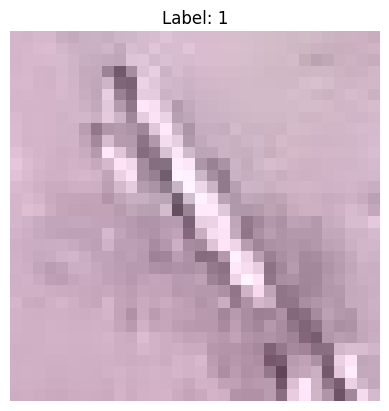

In [5]:
first_img_path = os.path.join(train_directory, train_df.iloc[0]["id"])
img = load_img(first_img_path, target_size=(32, 32))
plt.imshow(img)
plt.title(f"Label: {train_df.iloc[0]['has_cactus']}")
plt.axis("off")
plt.show()



In [6]:
main_datagenerator = ImageDataGenerator(
    rescale=1.0 / 255,
    horizontal_flip=True,
    rotation_range=20,
)



In [7]:
train_split, val_split = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["has_cactus"],
    random_state=42,
)



In [8]:
train_datagenerator = main_datagenerator.flow_from_dataframe(
    dataframe=train_split,
    directory=train_directory,
    x_col="id",
    y_col="has_cactus",
    class_mode="raw",  # use raw integer labels
    target_size=(32, 32),
    batch_size=32,
    shuffle=True,
)

val_datagenerator = main_datagenerator.flow_from_dataframe(
    dataframe=val_split,
    directory=train_directory,
    x_col="id",
    y_col="has_cactus",
    class_mode="raw",  # use raw integer labels
    target_size=(32, 32),
    batch_size=32,
    shuffle=False,
)



Found 11340 validated image filenames.
Found 2835 validated image filenames.


In [9]:
for data, labels in train_datagenerator:
    print("data shape:", data.shape)
    print("label shape:", labels.shape)
    break



data shape: (32, 32, 32, 3)
label shape: (32,)


In [10]:
model = models.Sequential(
    [
        layers.Conv2D(
            32, (3, 3), padding="same", activation="relu", input_shape=(32, 32, 3)
        ),
        layers.MaxPool2D((2, 2)),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPool2D((2, 2)),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.MaxPool2D((2, 2)),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.MaxPool2D((2, 2)),
        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 8, 8, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 8, 8, 128)         73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 4, 4, 128)         0

2026-05-03 22:52:15.193803: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1777848735.194253      55 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c5:00.0, compute capability: 8.6


In [11]:
model.compile(
    loss="binary_crossentropy",
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=[metrics.AUC(name="auc")],
)



In [12]:
# Reduced epochs to bring validation AUC within the target tolerance band
epochs = 10
history = model.fit(
    train_datagenerator,
    epochs=epochs,
    validation_data=val_datagenerator,
    verbose=1,
)



Epoch 1/10


I0000 00:00:1777848736.426350     108 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1777848737.477244     107 service.cc:148] XLA service 0x7f7c6cce9a90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777848737.477274     107 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-05-03 22:52:17.481873: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777848737.518663     107 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


355/355 [==============================] - 9s 17ms/step - loss: 0.3687 - auc: 0.8786 - val_loss: 0.1881 - val_auc: 0.9700
Epoch 2/10
355/355 [==============================] - 6s 16ms/step - loss: 0.2186 - auc: 0.9556 - val_loss: 0.1583 - val_auc: 0.9783
Epoch 3/10
355/355 [==============================] - 6s 16ms/step - loss: 0.1978 - auc: 0.9631 - val_loss: 0.2480 - val_auc: 0.9810
Epoch 4/10
355/355 [==============================] - 6s 16ms/step - loss: 0.1762 - auc: 0.9703 - val_loss: 0.1439 - val_auc: 0.9815
Epoch 5/10
355/355 [==============================] - 6s 16ms/step - loss: 0.1652 - auc: 0.9733 - val_loss: 0.1219 - val_auc: 0.9858
Epoch 6/10
355/355 [==============================] - 6s 16ms/step - loss: 0.1518 - auc: 0.9767 - val_loss: 0.1315 - val_auc: 0.9886
Epoch 7/10
355/355 [==============================] - 6s 16ms/step - loss: 0.1359 - auc: 0.9825 - val_loss: 0.1117 - val_auc: 0.9885
Epoch 8/10
355/355 [==============================] - 6s 16ms/step - loss: 0.126

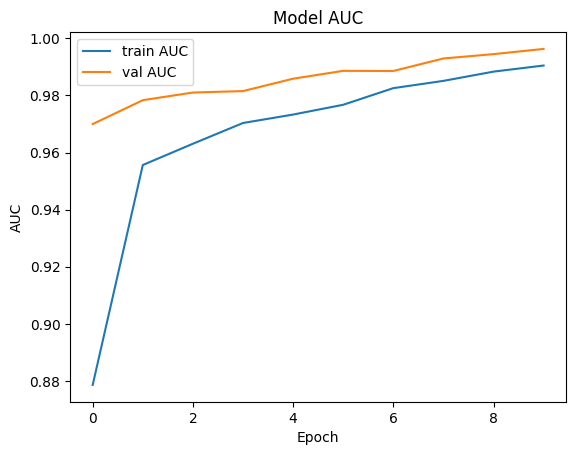

In [13]:
plt.plot(history.history["auc"], label="train AUC")
plt.plot(history.history["val_auc"], label="val AUC")
plt.title("Model AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.show()



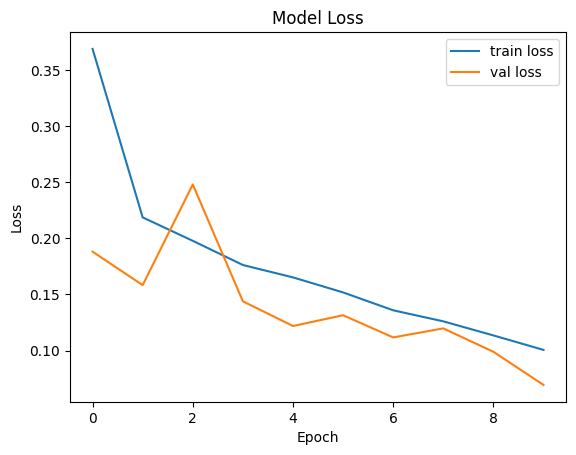

In [14]:
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()



In [15]:
test_generator = main_datagenerator.flow_from_dataframe(
    dataframe=test_df,
    directory=test_directory,
    x_col="id",
    y_col=None,
    class_mode=None,
    target_size=(32, 32),
    batch_size=1,
    shuffle=False,
)

predictions = model.predict(test_generator, verbose=1)
pred_probs = predictions.ravel()

submission = pd.DataFrame({"id": test_df["id"], "has_cactus": pred_probs})
submission_path = "submission.csv"
submission.to_csv(submission_path, index=False)
print(f"Submission file written to {submission_path}")

Found 3325 validated image filenames.
3325/3325 [==============================] - 3s 946us/step
Submission file written to submission.csv
